In [1]:
%pip install -e ..

Obtaining file:///Users/pratikeliasjacob/Documents/Projects/simple-transformer
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for simple-transformer (pyproject.toml) ... done
  Created wheel for simple-transformer: filename=simple_transformer-0.1.0-0.editable-py3-none-any.whl size=2215 sha256=4b0e54b79efa594ff50de136d37f9b7e9231bce41e124548d0bba9840dee41e4
  Stored in directory: /private/var/folders/qn/79klx_zs0m1fqrh1q4c5ql_00000gn/T/pip-ephem-wheel-cache-6rm0_7es/wheels/de/d4/87/c813e0cb6465938cfd1c4350e8aa954bcfb9b50edc775763b4
Successfully built simple-transformer
  Attempting uninstall: simple-transformer
    Found existing installation: simple-transformer 0.1.0
    Uninstalling simple-transformer-0.1.0:
      Successfully uninstalled simple-transformer-0.1.0
Note: you may need to restart the kernel to 

In [14]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from simple_transformer.checkpoint import CheckpointConfig, CheckpointManager
from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.metrics import TensorBoardTrainingObserver
from simple_transformer.model import SimpleTransformerLM, count_parameters
from simple_transformer.data import make_arithmetic_dataset, make_train_val_loaders
from simple_transformer.train import fit


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0
cpu


In [4]:
custom_examples = [
    "0+0=",
    "5+7=",
    "45-54=",
    "99-1=",
    "12*3=",
    "9*9=",
    "20/4=",
    "9/2=",
    "123+456=",
    "745-84=",
    "11*11=",
    "100/3=",
    "999+1=",
    "999-100=",
    "99*12=",
    "999/7=",
]

for example in custom_examples:
    print(example)


0+0=
5+7=
45-54=
99-1=
12*3=
9*9=
20/4=
9/2=
123+456=
745-84=
11*11=
100/3=
999+1=
999-100=
99*12=
999/7=


In [5]:
def show_generations(model, tokenizer, examples):
    model.eval()
    prompt_ids = [tokenizer.encode(example) for example in examples]
    generated_ids = model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

    for prompt, output_ids in zip(examples, generated_ids):
        print(f"{prompt:>8} -> {tokenizer.decode(output_ids)}")

In [6]:
train_config = local_training_config(max_digits=3, device=device)

model_config = small_model_config(
    max_digits=train_config.max_digits,
    device=train_config.device,
)
model = SimpleTransformerLM(model_config)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)
run_name = datetime.now().strftime("arithmetic-%Y%m%d-%H%M%S")
run_dir = Path("..") / "runs" / run_name
checkpoint_dir = Path("..") / "checkpoints" / run_name
checkpoint_manager = CheckpointManager(
    CheckpointConfig(checkpoint_dir=checkpoint_dir, keep_last=3)
)
observer = TensorBoardTrainingObserver(run_dir)
observer.log_config(
    training_config=train_config,
    model_config=model_config,
    parameter_count=count_parameters(model),
)

print(f"parameters: {count_parameters(model):,}")
print(f"force flash: {model_config.force_flash}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print(f"TensorBoard log dir: {run_dir}")
print(f"Checkpoint dir: {checkpoint_dir}")
print("Terminal: tensorboard --logdir runs")
print("Before training:")
show_generations(model, tokenizer, custom_examples)


parameters: 2,032,896
force flash: False
train batches: 1024, validation batches: 256
TensorBoard log dir: ../runs/arithmetic-20260619-221650
Checkpoint dir: ../checkpoints/arithmetic-20260619-221650
Terminal: tensorboard --logdir runs
Before training:
    0+0= -> 0+0=///////6666
    5+7= -> 5+7=+++++++++++
  45-54= -> 45-54=888888888
   99-1= -> 99-1=5555555555
   12*3= -> 12*3===========
    9*9= -> 9*9=44444444444
   20/4= -> 20/4===========
    9/2= -> 9/2=00000000000
123+456= -> 123+456========
 745-84= -> 745-84==+++++++
  11*11= -> 11*11==========
  100/3= -> 100/3==========
  999+1= -> 999+1=555555555
999-100= -> 999-100=5555555
  99*12= -> 99*12=555555555
  999/7= -> 999/7=000000000


In [7]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )

try:
    history = fit(
        model,
        train_loader,
        val_loader,
        train_config,
        on_epoch=print_epoch,
        observer=observer,
        checkpoint_manager=checkpoint_manager,
    )
finally:
    observer.close()
    checkpoint_manager.close()


epoch 01 | train loss 1.4942 acc 0.445 | val loss 1.2659 acc 0.513 | lr 2.98e-04
epoch 02 | train loss 1.2074 acc 0.529 | val loss 1.1506 acc 0.547 | lr 2.93e-04
epoch 03 | train loss 1.1258 acc 0.558 | val loss 1.0797 acc 0.577 | lr 2.85e-04
epoch 04 | train loss 0.8995 acc 0.649 | val loss 0.7717 acc 0.701 | lr 2.74e-04
epoch 05 | train loss 0.6335 acc 0.756 | val loss 0.5823 acc 0.772 | lr 2.61e-04
epoch 06 | train loss 0.5497 acc 0.787 | val loss 0.5487 acc 0.788 | lr 2.44e-04
epoch 07 | train loss 0.5178 acc 0.799 | val loss 0.5097 acc 0.800 | lr 2.26e-04
epoch 08 | train loss 0.4932 acc 0.808 | val loss 0.4887 acc 0.810 | lr 2.07e-04
epoch 09 | train loss 0.4740 acc 0.815 | val loss 0.4761 acc 0.812 | lr 1.86e-04
epoch 10 | train loss 0.4581 acc 0.820 | val loss 0.4596 acc 0.818 | lr 1.65e-04
epoch 11 | train loss 0.4412 acc 0.826 | val loss 0.4531 acc 0.819 | lr 1.44e-04
epoch 12 | train loss 0.4272 acc 0.832 | val loss 0.4326 acc 0.827 | lr 1.23e-04
epoch 13 | train loss 0.4119

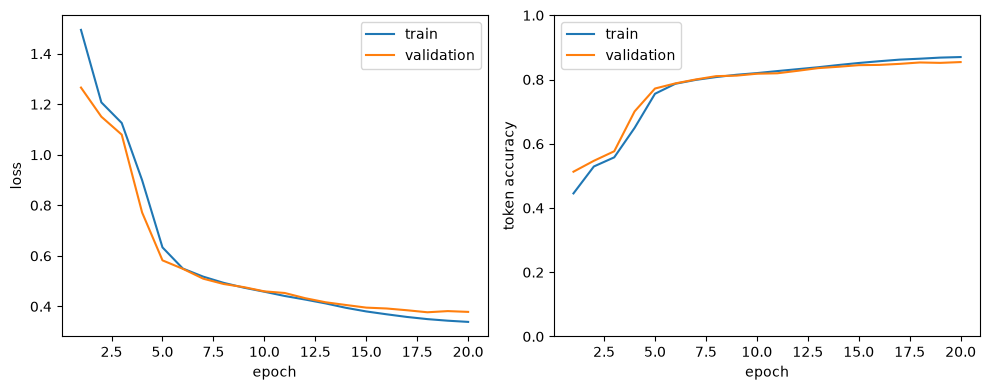

In [8]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [9]:
print("After training:")
show_generations(model, tokenizer, custom_examples)

final_train = history.train[-1]
final_validation = history.validation[-1]
print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)

After training:
    0+0= -> 0+0=0
    5+7= -> 5+7=22
  45-54= -> 45-54=-11
   99-1= -> 99-1=99
   12*3= -> 12*3=32
    9*9= -> 9*9=888
   20/4= -> 20/4=0
    9/2= -> 9/2=1
123+456= -> 123+456=579
 745-84= -> 745-84=661
  11*11= -> 11*11=133
  100/3= -> 100/3=3
  999+1= -> 999+1=1000
999-100= -> 999-100=899
  99*12= -> 99*12=1198
  999/7= -> 999/7=140
final train loss=0.3387, train acc=0.870, val loss=0.3783, val acc=0.854


In [10]:
latest_checkpoint = checkpoint_manager.latest_checkpoint()
print(f"latest checkpoint: {latest_checkpoint}\n")

inference_model = SimpleTransformerLM(model_config)
checkpoint_manager.load_checkpoint(
    latest_checkpoint,
    model=inference_model,
    map_location=device,
)
inference_model = inference_model.to(device)

show_generations(inference_model, tokenizer, custom_examples)

latest checkpoint: ../checkpoints/arithmetic-20260619-221650/epoch-0020.pt

    0+0= -> 0+0=0
    5+7= -> 5+7=22
  45-54= -> 45-54=-11
   99-1= -> 99-1=99
   12*3= -> 12*3=32
    9*9= -> 9*9=888
   20/4= -> 20/4=0
    9/2= -> 9/2=1
123+456= -> 123+456=579
 745-84= -> 745-84=661
  11*11= -> 11*11=133
  100/3= -> 100/3=3
  999+1= -> 999+1=1000
999-100= -> 999-100=899
  99*12= -> 99*12=1198
  999/7= -> 999/7=140


In [19]:
# Evaluate exact-match accuracy on 100 randomly generated examples.

random_examples = make_arithmetic_dataset(
    num_examples=100,
    max_digits=3,
    operations=train_config.operations,
    seed=train_config.seed + 1,
)
prompts = [example.text.split("=")[0] + "=" for example in random_examples]
prompt_ids = [tokenizer.encode(prompt) for prompt in prompts]

inference_model.eval()
with torch.no_grad():
    outputs = inference_model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

predictions = [tokenizer.decode(output.tolist()) for output in outputs]
targets = [example.text for example in random_examples]
wrong_cases = [
    (prompt, target, prediction)
    for prompt, target, prediction in zip(prompts, targets, predictions)
    if prediction != target
]
accuracy = (len(targets) - len(wrong_cases)) / len(targets)

print(f"accuracy: {accuracy:.2%} ({len(targets) - len(wrong_cases)}/{len(targets)})")
print(f"wrong cases: {len(wrong_cases)}")

for prompt, target, prediction in wrong_cases:
    print(f"{prompt:>12} expected {target:<18} got {prediction}")

accuracy: 80.00% (80/100)
wrong cases: 20
      98+27= expected 98+27=125          got 98+27=124
      255-6= expected 255-6=249          got 255-6=259
    340*373= expected 340*373=126820     got 340*373=126020
    510*142= expected 510*142=72420      got 510*142=72500
    145*327= expected 145*327=47415      got 145*327=46445
    320*267= expected 320*267=85440      got 320*267=85940
    376*745= expected 376*745=280120     got 376*745=289800
    121*734= expected 121*734=88814      got 121*734=88944
    338*541= expected 338*541=182858     got 338*541=189998
    111*706= expected 111*706=78366      got 111*706=77966
    407*355= expected 407*355=144485     got 407*355=144995
    224*133= expected 224*133=29792      got 224*133=30252
      150+2= expected 150+2=152          got 150+2=150
    732*444= expected 732*444=325008     got 732*444=325088
    227*353= expected 227*353=80131      got 227*353=82001
     623/19= expected 623/19=33          got 623/19=34
    281*910= expected 281